# IndabaX Botswana Hackathon 2026
## Forecasting Botswana's Food Price Inflation Under Global Economic Shocks

### Notebook 02: Feature Selection & Correlation Analysis

**Purpose:** Selects a defensible subset of features from the full
merged/lagged dataset (Notebook 01 output), combining domain
reasoning (causal transmission chains from Brent, BDI, policy rate,
and regional food inflation to Botswana's target) with empirical
correlation analysis against the target variable. Identifies and
documents the forecast-safety constraint (all source data ends
Dec 2023) and finalises the 8-feature, lag-12-only set used for
modelling.

**Input:** `data/processed/data_with_lags.csv`
**Output:** `data/processed/model_ready_data.csv`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [23]:
import os
print(os.getcwd())
os.listdir('../data/processed')
os.makedirs('../outputs/figures', exist_ok=True )
os.makedirs('../outputs/models', exist_ok=True)

/Volumes/AM_EXT/projects_2026/VenturePulse_Team[Biobytes]/notebooks


In [7]:
# load data
data_df = pd.read_csv('../data/processed/merged_monthly_features.csv', parse_dates=['year_month'])
print(data_df.shape)
print(data_df.head())
print(data_df.dtypes)

# checking missing values across the whole dataset

print(data_df.isnull().sum())
print(data_df.iloc[:, 0].value_counts())

(288, 44)
  year_month  year  month  month_sin     month_cos  \
0 2000-01-01  2000      1   0.500000  8.660254e-01   
1 2000-02-01  2000      2   0.866025  5.000000e-01   
2 2000-03-01  2000      3   1.000000  6.123234e-17   
3 2000-04-01  2000      4   0.866025 -5.000000e-01   
4 2000-05-01  2000      5   0.500000 -8.660254e-01   

   target_food_price_inflation  fao_cp_23012  fao_cp_23013  fao_cp_23014  \
0                          NaN     31.748320     31.912372           NaN   
1                          NaN     31.974914     32.163038           NaN   
2                          NaN     32.277040     32.413704           NaN   
3                          NaN     32.679873     32.612508           NaN   
4                          NaN     32.881290     32.811312           NaN   

   fao_food_index_mom_pct  ...  hcp_ken_fao_cp_23014  hcp_nam_fao_cp_23012  \
0                     NaN  ...                   NaN             35.757755   
1                0.785482  ...                   NaN

In [8]:
# load data with lags
lags_df = pd.read_csv('../data/processed/modelling_table_with_lags.csv', parse_dates=['year_month'])
print(lags_df.shape)
print(lags_df.head())
print(lags_df.dtypes)

# checking missing values across the whole dataset

print(lags_df.isnull().sum())
print(lags_df.iloc[:, 0].value_counts())

(276, 264)
  year_month  year  month  month_sin     month_cos  \
0 2001-01-01  2001      1   0.500000  8.660254e-01   
1 2001-02-01  2001      2   0.866025  5.000000e-01   
2 2001-03-01  2001      3   1.000000  6.123234e-17   
3 2001-04-01  2001      4   0.866025 -5.000000e-01   
4 2001-05-01  2001      5   0.500000 -8.660254e-01   

   target_food_price_inflation  fao_cp_23012  fao_cp_23013  fao_cp_23014  \
0                     3.602384     34.291207     33.061978      3.602384   
1                     3.359312     34.341562     33.243495      3.359312   
2                     2.720000     34.643687     33.295356      2.720000   
3                     2.173337     34.794749     33.321287      2.173337   
4                     2.028451     35.273114     33.476873      2.028451   

   fao_food_index_mom_pct  ...  fao_cp_23013_roll12_mean  \
0                0.314713  ...                 32.835802   
1                0.549020  ...                 32.925840   
2                0.156003  

In [10]:
print('merged data')
print(data_df.columns.tolist())
print('data with lags')
print(lags_df.columns.tolist())

merged data
['year_month', 'year', 'month', 'month_sin', 'month_cos', 'target_food_price_inflation', 'fao_cp_23012', 'fao_cp_23013', 'fao_cp_23014', 'fao_food_index_mom_pct', 'fao_food_index_yoy_pct_calc', 'bdi_close_mean', 'bdi_close_sd', 'bdi_close_min', 'bdi_close_max', 'bdi_close_first', 'bdi_close_last', 'bdi_high_mean', 'bdi_low_mean', 'bdi_trading_days', 'bdi_close_range', 'bdi_close_change_abs', 'bdi_close_change_pct', 'brent_usd_per_barrel', 'brent_mom_pct', 'brent_yoy_pct', 'policy_rate', 'policy_rate_change_1m', 'policy_rate_change_12m', 'hcp_bwa_fao_cp_23012', 'hcp_bwa_fao_cp_23013', 'hcp_bwa_fao_cp_23014', 'hcp_ken_fao_cp_23012', 'hcp_ken_fao_cp_23013', 'hcp_ken_fao_cp_23014', 'hcp_nam_fao_cp_23012', 'hcp_nam_fao_cp_23013', 'hcp_nam_fao_cp_23014', 'hcp_zaf_fao_cp_23012', 'hcp_zaf_fao_cp_23013', 'hcp_zaf_fao_cp_23014', 'hcp_zwe_fao_cp_23012', 'hcp_zwe_fao_cp_23013', 'hcp_zwe_fao_cp_23014']
data with lags
['year_month', 'year', 'month', 'month_sin', 'month_cos', 'target_food

Text(0.5, 1.0, 'Correlation with target_food_price_inflation')

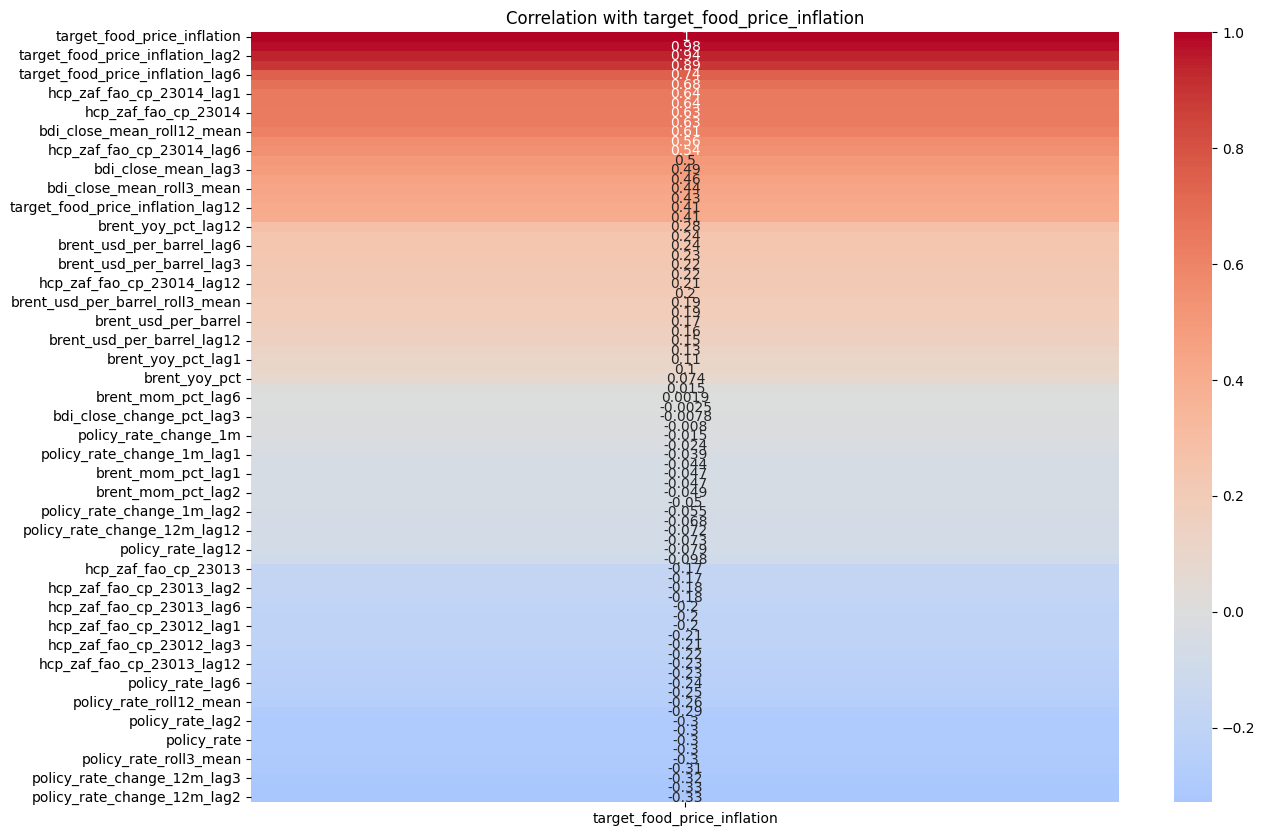

In [12]:
# checkig correlation between the features and target
# wider candidate pool - grab all lag versions of key economic variables
candidate_cols = [c for c in lags_df.columns if any(
    key in c for key in ['brent', 'bdi_close_mean', 'bdi_close_change_pct', 'policy_rate', 'hcp_zaf', 'target_food_price_inflation_lag']
)]

corr_matrix = lags_df[candidate_cols + ['target_food_price_inflation']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix[['target_food_price_inflation']].sort_values('target_food_price_inflation', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with target_food_price_inflation')


In [14]:
# narrowing dataset based on strong features from heatmap
selected_cols = [
    'year_month', 'target_food_price_inflation',  # date + target
    
    # Autoregressive structure
    'target_food_price_inflation_lag1',
    'target_food_price_inflation_lag2',
    'target_food_price_inflation_lag12',
    
    # South Africa leads Botswana (strongest external signal)
    'hcp_zaf_fao_cp_23014',
    'hcp_zaf_fao_cp_23014_lag1',
    'hcp_zaf_fao_cp_23014_lag6',
    
    # Shipping cost trend (BDI)
    'bdi_close_mean_roll12_mean',
    'bdi_close_mean_lag3',
    
    # Policy rate (inverse relationship - rate hikes suppress inflation)
    'policy_rate',
    'policy_rate_lag2',
    'policy_rate_change_12m_lag2',
    
    # Oil price pass-through (longer lag than guide suggested )
    'brent_usd_per_barrel_lag6',
    'brent_yoy_pct_lag12',
    
    # Calendar seasonality
    'month_sin',
    'month_cos'
]

model_df = lags_df[selected_cols].copy()
print(model_df.shape)
print(model_df.isna().sum())


(276, 17)
year_month                            0
target_food_price_inflation           0
target_food_price_inflation_lag1      1
target_food_price_inflation_lag2      2
target_food_price_inflation_lag12    12
hcp_zaf_fao_cp_23014                  0
hcp_zaf_fao_cp_23014_lag1             1
hcp_zaf_fao_cp_23014_lag6             6
bdi_close_mean_roll12_mean            0
bdi_close_mean_lag3                   0
policy_rate                           0
policy_rate_lag2                      0
policy_rate_change_12m_lag2           2
brent_usd_per_barrel_lag6             0
brent_yoy_pct_lag12                  12
month_sin                             0
month_cos                             0
dtype: int64


In [15]:
model_df_clean = model_df.dropna().reset_index(drop=True)
print(model_df_clean.shape)

(264, 17)


AttributeError: 'DataFrame' object has no attribute 'cum'

In [18]:
model_df_clean.to_csv('../data/processed/model_ready_data.csv', index=False)

In [20]:
print([c for c in lags_df.columns if 'lag12' in c])

['target_food_price_inflation_lag12', 'fao_cp_23012_lag12', 'fao_cp_23013_lag12', 'month_sin_lag12', 'month_cos_lag12', 'fao_cp_23014_lag12', 'fao_food_index_mom_pct_lag12', 'fao_food_index_yoy_pct_calc_lag12', 'bdi_close_mean_lag12', 'bdi_close_sd_lag12', 'bdi_close_min_lag12', 'bdi_close_max_lag12', 'bdi_close_first_lag12', 'bdi_close_last_lag12', 'bdi_high_mean_lag12', 'bdi_low_mean_lag12', 'bdi_trading_days_lag12', 'bdi_close_range_lag12', 'bdi_close_change_abs_lag12', 'bdi_close_change_pct_lag12', 'brent_usd_per_barrel_lag12', 'brent_mom_pct_lag12', 'brent_yoy_pct_lag12', 'policy_rate_lag12', 'policy_rate_change_1m_lag12', 'policy_rate_change_12m_lag12', 'hcp_bwa_fao_cp_23012_lag12', 'hcp_bwa_fao_cp_23013_lag12', 'hcp_bwa_fao_cp_23014_lag12', 'hcp_ken_fao_cp_23012_lag12', 'hcp_ken_fao_cp_23013_lag12', 'hcp_ken_fao_cp_23014_lag12', 'hcp_nam_fao_cp_23012_lag12', 'hcp_nam_fao_cp_23013_lag12', 'hcp_nam_fao_cp_23014_lag12', 'hcp_zaf_fao_cp_23012_lag12', 'hcp_zaf_fao_cp_23013_lag12', 'h

---
**➜ Next: `03_model_ets_arima.ipynb`** 